# AI4HWS - Wildfire Prediction Data Exploration

This notebook documents the data exploration and feature engineering process for wildfire prediction using geospatial raster data.

**Data Source**: wildfire dataset (25-year window)
**Focus**: Understanding data distributions, quality, relationships, and engineering features for machine learning

In [2]:
import rasterio
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Section 1: Load and Explore Raster Data

Discover all GeoTIFF files and verify they can be loaded properly.

In [3]:
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
data_dir = project_root / "data" / "raw"

# Find all .tif variations (case-insensitive)
tif_files = sorted({
    *data_dir.rglob("*.tif"),
    *data_dir.rglob("*.TIF"),
    *data_dir.rglob("*.tiff"),
    *data_dir.rglob("*.TIFF"),
})

print(f"Project root: {project_root}")
print(f"Data dir: {data_dir}")
print(f"Found {len(tif_files)} TIF files\n")

for i, f in enumerate(tif_files[:5], 1):
    print(f"{i}. {f.name}")

Project root: /Users/ali/aihws-ali
Data dir: /Users/ali/aihws-ali/data/raw
Found 11 TIF files

1. 1_road_dist.tif
2. LULC_2019.tif
3. NDVI_mean_aug.tif
4. NDVI_mean_march.tif
5. aspect.tif


## Section 2: Check TIFF Metadata and NoData Values

Analyze metadata to understand NoData handling and actual data ranges.

In [4]:
print("TIFF Metadata Analysis:")
print(f"{'Filename':<30} {'NoData (metadata)':<20} {'Data range':<25}")
print("=" * 75)

for tif_file in tif_files:
    with rasterio.open(tif_file) as src:
        nodata_meta = src.nodata
        data = src.read(1).astype(float)
        
        # Get actual min/max of raw data
        print(f"{tif_file.stem:<30} {str(nodata_meta):<20} [{np.min(data):.2f} - {np.max(data):.2f}]")
        
        # Check what percentage of data matches the NoData value
        if nodata_meta is not None:
            nodata_pct = (data == nodata_meta).sum() / data.size * 100
            print(f"  → {nodata_pct:.2f}% matches NoData value ({nodata_meta})")

TIFF Metadata Analysis:
Filename                       NoData (metadata)    Data range               
1_road_dist                    -9999.0              [-9999.00 - 8422.00]
  → 49.58% matches NoData value (-9999.0)
LULC_2019                      250.0                [11.00 - 250.00]
  → 36.37% matches NoData value (250.0)
NDVI_mean_aug                  None                 [nan - nan]
NDVI_mean_march                -9999.0              [-9999.00 - 0.43]
  → 36.10% matches NoData value (-9999.0)
aspect                         -9999.0              [-9999.00 - 359.96]
  → 38.15% matches NoData value (-9999.0)
max_temp_aug                   -9999.0              [-9999.00 - 39.44]
  → 35.39% matches NoData value (-9999.0)
mean_precipitation             -3.4028234663852886e+38 [-340282346638528859811704183484516925440.00 - 1121.93]
  → 29.69% matches NoData value (-3.4028234663852886e+38)
mean_temp                      -3.4028234663852886e+38 [-340282346638528859811704183484516925440.00 - 

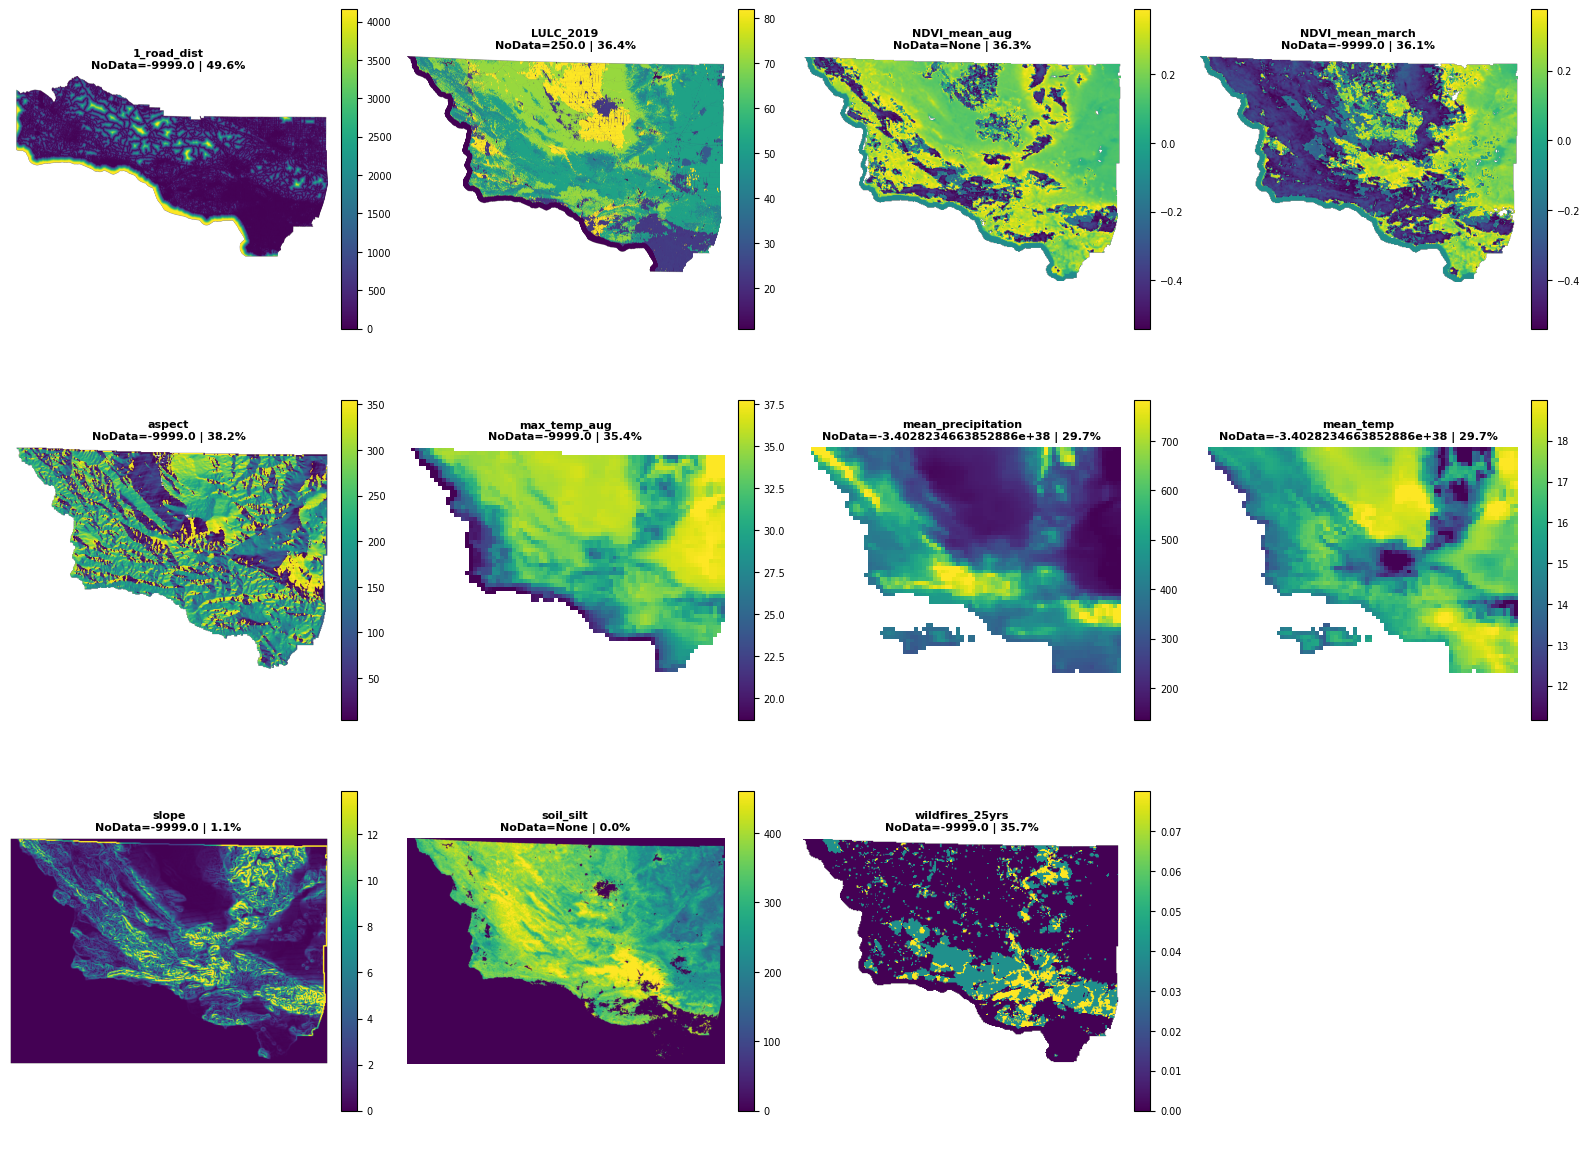

✅ Raster visualization saved


In [ ]:
plt.tight_layout()
plt.savefig(project_root / "data" / "tif_overview.png", dpi=100, bbox_inches='tight')
plt.show()

print("Raster visualization saved")

## Section 2.5: Resample Rasters to Common Grid

Align all rasters to a reference grid (wildfires_25yrs) using bilinear interpolation.

In [ ]:
from rasterio.warp import reproject, Resampling
import os

reference_name = 'wildfires_25yrs.tif'
reference_file = None

for f in tif_files:
    if f.name == reference_name:
        reference_file = f
        break

if reference_file is None:
    print(f"Reference file {reference_name} not found!")
else:
    aligned_dir = project_root / "data" / "preprocessed"
    aligned_dir.mkdir(exist_ok=True)
    
    with rasterio.open(reference_file) as ref:
        ref_shape = ref.shape
        ref_transform = ref.transform
        ref_crs = ref.crs
    
    print(f"Resampling all rasters to {ref_shape}...")
    
    aligned_files = []
    for tif_file in tif_files:
        with rasterio.open(tif_file) as src:
            resampled_data = np.empty(ref_shape, dtype=src.dtypes[0])
            reproject(
                source=rasterio.band(src, 1),
                destination=resampled_data,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.bilinear,
                src_nodata=src.nodata,
                dst_nodata=src.nodata
            )
            output_file = aligned_dir / tif_file.name
            with rasterio.open(
                output_file, 'w',
                driver='GTiff',
                height=ref_shape[0],
                width=ref_shape[1],
                count=1,
                dtype=src.dtypes[0],
                crs=ref_crs,
                transform=ref_transform,
                nodata=src.nodata
            ) as dst:
                dst.write(resampled_data, 1)
            aligned_files.append(output_file)
            print(f"  {tif_file.name} → {ref_shape}")
    
    print(f"\nAll {len(aligned_files)} rasters aligned and saved")
    tif_files = sorted(aligned_dir.glob("*.tif"))

Reference raster: wildfires_25yrs.tif
  Shape: (244, 344)
  CRS: EPSG:32611
  Bounds: BoundingBox(left=99795.8828, bottom=3726167.5, right=443795.8828, top=3970167.5)

Resampling all rasters to (244, 344)...

✓ 1_road_dist.tif                → (244, 344)
✓ LULC_2019.tif                  → (244, 344)
✓ NDVI_mean_aug.tif              → (244, 344)
✓ NDVI_mean_march.tif            → (244, 344)
✓ aspect.tif                     → (244, 344)
✓ max_temp_aug.tif               → (244, 344)
✓ mean_precipitation.tif         → (244, 344)
✓ mean_temp.tif                  → (244, 344)
✓ slope.tif                      → (244, 344)
✓ soil_silt.tif                  → (244, 344)
✓ wildfires_25yrs.tif            → (244, 344)

✅ All 11 rasters aligned and saved to /Users/ali/aihws-ali/data/preprocessed/
✓ Using aligned rasters for next steps


In [9]:
# Verify all rasters are now the same shape
print("Verifying resampled rasters are aligned:\n")
shapes_aligned = {}
for tif_file in tif_files:
    with rasterio.open(tif_file) as src:
        shapes_aligned[tif_file.name] = src.shape

unique_shapes = set(shapes_aligned.values())
print(f"Unique shapes after resampling: {unique_shapes}")

if len(unique_shapes) == 1:
    print(f"\n✅ SUCCESS! All rasters now have shape: {unique_shapes.pop()}")
else:
    print(f"\n⚠️  Still have {len(unique_shapes)} different shapes (check resampling)")

Verifying resampled rasters are aligned:

Unique shapes after resampling: {(244, 344)}

✅ SUCCESS! All rasters now have shape: (244, 344)


## Section 3: Convert Rasters to Tabular Format

Convert all aligned rasters into a pandas DataFrame with one row per pixel.

In [10]:
def rasters_to_dataframe(tif_files):
    """Convert raster files to a pandas DataFrame with one row per pixel"""
    
    # First check if all rasters have the same shape
    shapes = {}
    for tif_file in tif_files:
        with rasterio.open(tif_file) as src:
            shapes[tif_file.name] = src.shape
    
    print("Raster shapes:")
    unique_shapes = set(shapes.values())
    for name, shape in shapes.items():
        print(f"  {name}: {shape}")
    
    if len(unique_shapes) > 1:
        print(f"\n⚠️  WARNING: Found {len(unique_shapes)} different shapes!")
        print("All rasters must have the same dimensions.")
        return None
    
    print(f"\n✓ All rasters have the same shape: {unique_shapes.pop()}")
    
    data_dict = {}
    
    for tif_file in tif_files:
        with rasterio.open(tif_file) as src:
            data = src.read(1).astype(float)
            nodata_value = src.nodata
            
            # Replace NoData with NaN
            if nodata_value is not None:
                data[data == nodata_value] = np.nan
            
            # Flatten to 1D array
            data_dict[tif_file.stem] = data.flatten()
    
    # Create DataFrame
    df = pd.DataFrame(data_dict)
    
    # Remove rows where ALL values are NaN (ocean/outside study area)
    df_clean = df.dropna(how='all')
    
    print(f"\nTotal pixels: {len(df):,}")
    print(f"Valid pixels (not all NaN): {len(df_clean):,}")
    print(f"Percentage kept: {len(df_clean)/len(df)*100:.2f}%")
    print(f"\nDataFrame shape: {df_clean.shape}")
    print(f"Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return df_clean

# Convert rasters to DataFrame
df_wildfire = rasters_to_dataframe(tif_files)
if df_wildfire is not None:
    print("\nFirst 5 rows:")
    display(df_wildfire.head())

Raster shapes:
  1_road_dist.tif: (244, 344)
  LULC_2019.tif: (244, 344)
  NDVI_mean_aug.tif: (244, 344)
  NDVI_mean_march.tif: (244, 344)
  aspect.tif: (244, 344)
  max_temp_aug.tif: (244, 344)
  mean_precipitation.tif: (244, 344)
  mean_temp.tif: (244, 344)
  slope.tif: (244, 344)
  soil_silt.tif: (244, 344)
  wildfires_25yrs.tif: (244, 344)

✓ All rasters have the same shape: (244, 344)

Total pixels: 83,936
Valid pixels (not all NaN): 83,936
Percentage kept: 100.00%

DataFrame shape: (83936, 11)
Memory usage: 7.04 MB

First 5 rows:


,1_road_dist,LULC_2019,NDVI_mean_aug,NDVI_mean_march,aspect,max_temp_aug,mean_precipitation,mean_temp,slope,soil_silt,wildfires_25yrs
0,NaN,11.0,NaN,-0.088,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,NaN,11.0,NaN,-0.088,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,NaN,11.0,NaN,-0.088,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,NaN,11.0,-0.088,-0.088,NaN,17.023666,711.233337,13.776733,NaN,0.0,0.0
4,NaN,11.0,-0.088,-0.088,NaN,17.023666,711.233337,13.776733,NaN,0.0,0.0


## Section 4: Exploratory Data Analysis

Understand data distributions, relationships, and quality.

In [11]:
print("Missing Values Analysis:")
print("=" * 60)
missing_pct = (df_wildfire.isnull().sum() / len(df_wildfire) * 100).sort_values(ascending=False)
for col, pct in missing_pct.items():
    print(f"{col:<30} {pct:>6.2f}% missing")

print("\n" + "=" * 60)
print(f"Rows with ANY missing values: {df_wildfire.isnull().any(axis=1).sum():,}")
print(f"Rows with NO missing values: {(~df_wildfire.isnull().any(axis=1)).sum():,}")

Missing Values Analysis:
1_road_dist                     72.10% missing
NDVI_mean_aug                   39.70% missing
aspect                          37.86% missing
max_temp_aug                    36.58% missing
LULC_2019                       35.75% missing
NDVI_mean_march                 35.73% missing
wildfires_25yrs                 35.68% missing
mean_precipitation              30.72% missing
mean_temp                       30.72% missing
slope                            0.70% missing
soil_silt                        0.00% missing

Rows with ANY missing values: 62,925
Rows with NO missing values: 21,011


In [12]:
# Basic statistics
print("\nBasic Statistics:")
print("=" * 60)
display(df_wildfire.describe())


Basic Statistics:


,1_road_dist,LULC_2019,NDVI_mean_aug,NDVI_mean_march,aspect,max_temp_aug,mean_precipitation,mean_temp,slope,soil_silt,wildfires_25yrs
count,23419.000000,53927.000000,50610.000000,53942.000000,52156.000000,53232.000000,58147.000000,58147.000000,83349.000000,83936.000000,53985.000000
mean,585.806968,53.613422,0.088515,-0.117485,181.245718,31.848428,366.822993,16.170549,2.468479,184.592451,0.015917
std,955.084282,16.830994,0.244035,0.288171,88.180384,4.691942,171.768377,1.860070,3.905630,170.440864,0.028744
min,0.764540,11.000000,-0.575019,-0.573202,0.000000,16.064771,105.271812,8.211786,0.000000,0.000000,0.000000
25%,90.251114,49.000000,-0.004048,-0.397169,110.520086,29.667608,211.161728,15.064531,0.000000,0.000000,0.000000
50%,216.747131,52.000000,0.171046,-0.164031,189.851242,33.041423,346.549347,16.362692,0.693237,214.000000,0.000000
75%,590.011780,67.000000,0.255654,0.181894,247.362907,35.427105,478.988693,17.670652,3.656476,348.000000,0.040000
max,7995.709961,95.000000,0.409601,0.414755,359.718994,39.434801,1099.305786,19.555010,59.514668,654.000000,0.400000


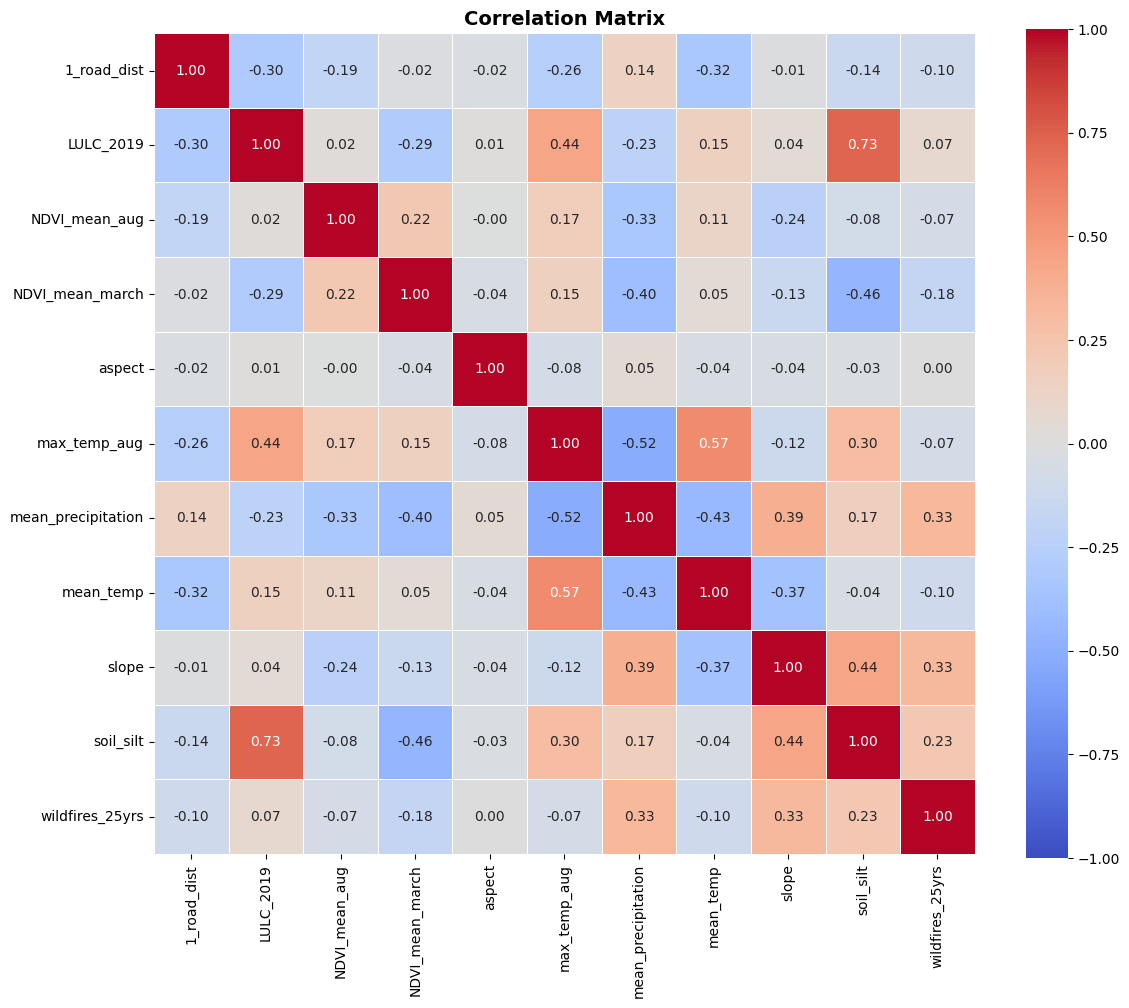


Top correlations with wildfire probability:
mean_precipitation               0.331
slope                            0.327
soil_silt                        0.233
LULC_2019                        0.074
aspect                           0.001
NDVI_mean_aug                   -0.070
max_temp_aug                    -0.071
1_road_dist                     -0.102
mean_temp                       -0.103
NDVI_mean_march                 -0.178


In [13]:
# Correlation analysis
correlation_matrix = df_wildfire.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(project_root / "data" / "correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Show highest correlations with target variable (if exists)
if 'wildfires_25yrs' in correlation_matrix.columns:
    print("\nTop correlations with wildfire probability:")
    print("=" * 60)
    correlations = correlation_matrix['wildfires_25yrs'].sort_values(ascending=False)
    for var, corr in correlations.items():
        if var != 'wildfires_25yrs':
            print(f"{var:<30} {corr:>7.3f}")

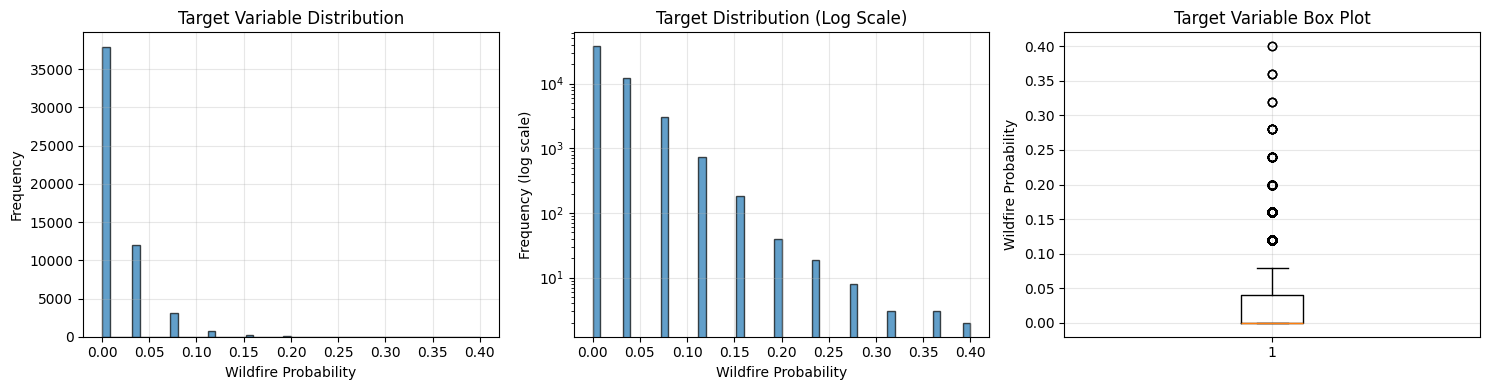

Target Variable Statistics:
  Mean: 0.0159
  Median: 0.0000
  Std: 0.0287
  Min: 0.0000
  Max: 0.4000
  Zeros: 37932 (45.2%)


In [14]:
# Target variable distribution
if 'wildfires_25yrs' in df_wildfire.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram
    axes[0].hist(df_wildfire['wildfires_25yrs'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Wildfire Probability')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Target Variable Distribution')
    axes[0].grid(True, alpha=0.3)
    
    # Log scale
    axes[1].hist(df_wildfire['wildfires_25yrs'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Wildfire Probability')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_title('Target Distribution (Log Scale)')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)
    
    # Box plot
    axes[2].boxplot(df_wildfire['wildfires_25yrs'].dropna())
    axes[2].set_ylabel('Wildfire Probability')
    axes[2].set_title('Target Variable Box Plot')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("Target Variable Statistics:")
    print(f"  Mean: {df_wildfire['wildfires_25yrs'].mean():.4f}")
    print(f"  Median: {df_wildfire['wildfires_25yrs'].median():.4f}")
    print(f"  Std: {df_wildfire['wildfires_25yrs'].std():.4f}")
    print(f"  Min: {df_wildfire['wildfires_25yrs'].min():.4f}")
    print(f"  Max: {df_wildfire['wildfires_25yrs'].max():.4f}")
    print(f"  Zeros: {(df_wildfire['wildfires_25yrs'] == 0).sum()} ({(df_wildfire['wildfires_25yrs'] == 0).sum()/len(df_wildfire)*100:.1f}%)")

## Section 5: Feature Engineering

Create derived features for machine learning models.

In [15]:
df_fe = df_wildfire.copy()

print('🔧 Creating engineered features...\n')

# --- Target decomposition ---
if 'wildfires_25yrs' in df_fe.columns:
    df_fe['fire_occurrence'] = (df_fe['wildfires_25yrs'] > 0).astype(int)
    df_fe['fire_magnitude'] = df_fe['wildfires_25yrs'].where(df_fe['wildfires_25yrs'] > 0, np.nan)
    print('✅ fire_occurrence, fire_magnitude')

# --- Skewness-aware log transforms ---
for col in ['slope', 'soil_silt']:
    if col in df_fe.columns:
        df_fe[f'{col}_log1p'] = np.log1p(df_fe[col].clip(lower=0))
        print(f'✅ {col}_log1p')

# --- Aspect sine/cosine ---
if 'aspect' in df_fe.columns:
    aspect_rad = np.deg2rad(df_fe['aspect'] % 360)
    df_fe['aspect_sin'] = np.sin(aspect_rad)
    df_fe['aspect_cos'] = np.cos(aspect_rad)
    print('✅ aspect_sin, aspect_cos')

# --- Interaction terms ---
if {'slope', 'mean_precipitation'}.issubset(df_fe.columns):
    df_fe['slope_x_precip'] = df_fe['slope'] * df_fe['mean_precipitation']
    print('✅ slope_x_precip')

if {'mean_temp', 'mean_precipitation'}.issubset(df_fe.columns):
    df_fe['temp_x_precip'] = df_fe['mean_temp'] * df_fe['mean_precipitation']
    print('✅ temp_x_precip')

# --- Seasonal vegetation ---
if {'NDVI_mean_march', 'NDVI_mean_aug'}.issubset(df_fe.columns):
    df_fe['NDVI_diff_seasonal'] = df_fe['NDVI_mean_aug'] - df_fe['NDVI_mean_march']
    print('✅ NDVI_diff_seasonal')

print(f'\n✅ Feature engineering complete')
print(f'Original columns: {df_wildfire.shape[1]}')
print(f'Engineered columns: {df_fe.shape[1]}')
print(f'Added: {df_fe.shape[1] - df_wildfire.shape[1]} features')

🔧 Creating engineered features...

✅ fire_occurrence, fire_magnitude
✅ slope_log1p
✅ soil_silt_log1p
✅ aspect_sin, aspect_cos
✅ slope_x_precip
✅ temp_x_precip
✅ NDVI_diff_seasonal

✅ Feature engineering complete
Original columns: 11
Engineered columns: 20
Added: 9 features


## Section 6: Data Preparation for Modeling

Clean data for machine learning models.

In [17]:
# Prepare clean dataset for modeling
df_model = df_fe.dropna(subset=['wildfires_25yrs']).copy() if 'wildfires_25yrs' in df_fe.columns else df_fe.copy()

print(f"Dataset after removing rows with missing target:")
print(f"  Rows: {len(df_model):,}")
print(f"  Columns: {len(df_model.columns)}")
print(f"  Fire occurrence: {(df_model['fire_occurrence'] == 1).sum():,} ({100*(df_model['fire_occurrence'] == 1).mean():.1f}%)")
print(f"  Non-fire: {(df_model['fire_occurrence'] == 0).sum():,} ({100*(df_model['fire_occurrence'] == 0).mean():.1f}%)")

# Check remaining missing values
missing_features = df_model.isnull().sum()
print(f"\nMissing values in features:")
print(missing_features[missing_features > 0])

# SAVE: Dataset with both fire and non-fire samples (for training Stage 1 classifier)
df_model.to_csv(project_root / 'data' / 'wildfire_data_for_training.csv', index=False)
print(f"\n✅ Training dataset saved (with both classes) → data/wildfire_data_for_training.csv")

# Option: Drop rows with any missing features (for validation)
df_complete = df_model.dropna()
print(f"\nComplete cases (no missing values): {len(df_complete):,} rows")

# Save cleaned dataset
df_complete.to_csv(project_root / 'data' / 'wildfire_data_clean.csv', index=False)
print(f"✅ Clean dataset saved (complete cases only) → data/wildfire_data_clean.csv")

print(f"\n{'='*60}")
print("🎯 DATA EXPLORATION COMPLETE")
print(f"{'='*60}")
print(f"\nDataset ready for modeling:")
print(f"  Training set (with both classes): {len(df_model):,} rows")
print(f"  Clean set (complete cases only):  {len(df_complete):,} rows")
print(f"  Features: {len(df_complete.columns)}")
print(f"  Memory: {df_complete.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset after removing rows with missing target:
  Rows: 53,985
  Columns: 20
  Fire occurrence: 16,053 (29.7%)
  Non-fire: 37,932 (70.3%)

Missing values in features:
1_road_dist           30568
LULC_2019               251
NDVI_mean_aug          3392
NDVI_mean_march         344
aspect                 2398
max_temp_aug           1080
mean_precipitation      906
mean_temp               906
slope                    13
fire_magnitude        37932
slope_log1p              13
aspect_sin             2398
aspect_cos             2398
slope_x_precip          916
temp_x_precip           906
NDVI_diff_seasonal     3562
dtype: int64

✅ Training dataset saved (with both classes) → data/wildfire_data_for_training.csv

Complete cases (no missing values): 10,771 rows
✅ Clean dataset saved (complete cases only) → data/wildfire_data_clean.csv

🎯 DATA EXPLORATION COMPLETE

Dataset ready for modeling:
  Training set (with both classes): 53,985 rows
  Clean set (complete cases only):  10,771 rows
  Feature